# Study of the full crossmatch

In this notebook we study the full crossmatch 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit

import copy
# Import own modules
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')
# Laptop
sys.path.append('/home/rens/projects/mp_dir/masterproject/src/')

from data_queries import query_extra_data
from plotting_functions import set_styles
from astrometry_equations import rayleigh, compute_error_normalized_distance, predict_G_bv, predict_G_vi

In [2]:
# Define Paths
fpath = '../../../figures/'
rpath = '../../results/'
dpath = '../../../data/'

set_styles()

In [3]:
def get_hipp_gaia_data(crossmatch_idxs, HippCat='Hipparcos_mix', GaiaCat='GaiaBaseCat+PMC+EIB'):
    # Hipparcos - Gaia indexes of the cross match 
    hipp_cat = fits.open(f'{dpath}{HippCat}.fits')[1].data
    gaia_cat = fits.open(f'{dpath}{GaiaCat}.fits')[1].data

    # Make a table matching the XM order containing all propagated Gaia astrometry
    pos_gaia_table_full = copy.deepcopy(gaia_cat)
    pos_gaia_table_full = pos_gaia_table_full[crossmatch_idxs[:,2]]

    # Indexing this table is slightly more work because we do not have the table idxs stored
    pos_hipp_table_full = copy.deepcopy(hipp_cat)

    hip_indexes = np.zeros(crossmatch_idxs.shape[0], dtype=np.int64)
    for i in range(crossmatch_idxs.shape[0]):
        hip_indexes[i] = int(np.where(hipp_cat['hip'] == crossmatch_idxs[i][0])[0][0])
    pos_hipp_table_full = pos_hipp_table_full[hip_indexes]

    return pos_hipp_table_full, pos_gaia_table_full

## Data
We have started by crossmatching all Hipparcos objects at 2, 3, 5 and 10 arcseconds. The resulting lengths are written out in the notebook, but @10" we have found a potential match for 117,812 / 117,955 Hipparcos objects. Each of these objects currently has a best neighbour catalogue selected using nearest and brightest which probably means a lot of objects are false matches. Let's start by checking the 'standard proxies':
- B-V predicted G versus crossmatched G
- Error Normalized Distance

In [4]:
all_2as = np.load(rpath+'final_crossmatch+PMC+EIB_2as_all_neighbours.npy') 
all_3as = np.load(rpath+'final_crossmatch+PMC+EIB_3as_all_neighbours.npy') 
all_5as = np.load(rpath+'final_crossmatch+PMC+EIB_5as_all_neighbours.npy') 
all_10as = np.load(rpath+'final_crossmatch+PMC+EIB_10as_all_neighbours.npy') 

In [ ]:
hipp_10as_all, gaia_10as_all = get_hipp_gaia_data(all_10as)

In [21]:
kervela_tab = fits.open(dpath+'kervela_pma.fits')

### Gaia Predicted versus real Gaia magnitude from crossmatch

For clarity, plot G - G_pred as a function of colour

In [ ]:
# B-V
G = pos_gaia_table_full['phot_g_mean_mag']
b_v = pos_hipp_table_full['b_v']
hp_mag = pos_hipp_table_full['hp_mag']
numsig = 5

G_pred_bv, pred_unc = predict_G_bv(hp_mag, b_v)
print(f'sigma = {pred_unc}')
good_predictions = len(G_pred_bv[np.abs(G-G_pred_bv) < numsig*pred_unc])
print(f'{good_predictions} object magnitudes well predicted within {numsig} sigma')

fig, ax = plt.subplots(1,1,figsize=(10,8))

scatter = ax.hexbin(b_v, G-G_pred_bv, bins='log',  mincnt=1, cmap='jet')
ax.axhline(y=numsig*pred_unc, c='black', ls='--', alpha=0, label=fr'{good_predictions} objects within {numsig}$\sigma$')
ax.axhline(y=-numsig*pred_unc, c='black',ls='--', alpha=0)
cb = plt.colorbar(scatter)

ax.set_xlabel('Hipparcos B-V Colour')
ax.set_ylabel(r'G - G$_{pred}$')
ax.set_title('Difference crossmatched and predicted G using B-V')
cb.set_label('Counts')

#plt.savefig(fpath+'G_vs_Gpred_10as_likeliest_pos.png', bbox_inches='tight')
plt.legend()
plt.show()

In [ ]:
# V-I
# B-V
G = pos_gaia_table_full['phot_g_mean_mag']
v_i = pos_hipp_table_full['v_i']
hp_mag = pos_hipp_table_full['hp_mag']

G_pred_vi, _ = predict_G_vi(hp_mag, v_i)



fig, ax = plt.subplots(1,1,figsize=(10,8))

#scatter = ax.scatter(b_v ,G - G_pred_bv, s=1, c=hp_mag, cmap='jet')
scatter = ax.hexbin(v_i, G-G_pred_vi, mincnt=1, cmap='jet')
plt.colorbar(scatter)
#ax.plot(x, y, c='black', ls='--')

ax.set_xlabel('Hipparcos V-I Colour')
ax.set_ylabel(r'G - G$_{pred}$')
ax.set_title('Difference between crossmatched and predicted G using V-I')

plt.show()

### Error Normalized Distance
Apparently also known as the Mahalanobis Distance

In [18]:
# Make correct arrays
# pos = [ra, dec] ; unc = [sigma_ra^2, sigma_dec^2, rho_sigma_dec]
pos_hipp = np.array([pos_hipp_table_full['ra'], pos_hipp_table_full['dec']]).T * 3.6e6
pos_gaia = np.array([pos_gaia_table_full['ra_prop'], pos_gaia_table_full['dec_prop']]).T * 3.6e6
unc_hipp = np.array([pos_hipp_table_full['e_ra_rad']**2, pos_hipp_table_full['e_de_rad']**2, pos_hipp_table_full['ra_dec_corr']]).T
unc_gaia = np.array([pos_gaia_table_full['e_ra_prop']**2, pos_gaia_table_full['e_de_prop']**2, pos_gaia_table_full['ra_dec_prop']]).T

In [184]:
D = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='full')

NameError: name 'pos_hipp' is not defined

In [23]:
print(f"""Error Normalized Distance (Mahabonis Distance):
Max:    {np.max(D):.2E}
Min:    {np.min(D):.2E}
Mean:   {np.mean(D):.2f}
Median: {np.median(D):.2f}
Std.:   {np.std(D):.2f}
""")

Error Normalized Distance (Mahabonis Distance):
Max:    6.16E+04
Min:    7.68E-05
Mean:   27.97
Median: 2.73
Std.:   306.67



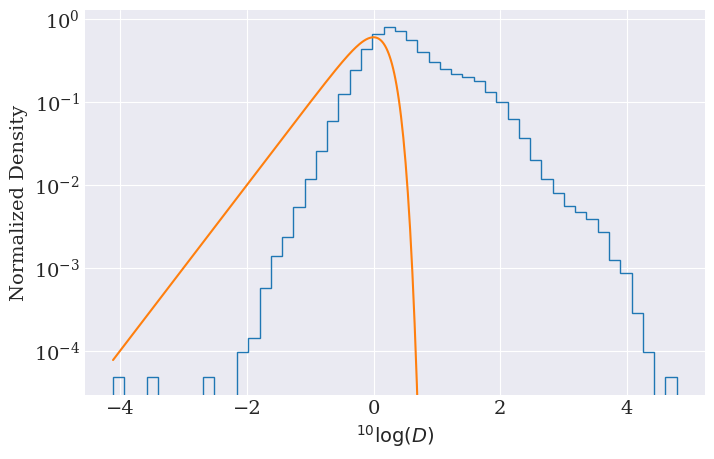

In [56]:
x_rayleigh = np.logspace(np.log10(np.nanmin(D)), np.log10(np.nanmax(D)), 500)
y_rayleigh = rayleigh(x_rayleigh, 1)

fig, ax = plt.subplots(1,1, figsize=(8,5))

ax.hist(np.log10(D), bins=50, histtype='step', log=True, density=True)
ylim = ax.get_ylim()
ax.plot(np.log10(x_rayleigh), y_rayleigh)
ax.set_ylim(ylim)

ax.set_xlabel(r'$^{10}\log(D)$')
ax.set_ylabel('Normalized Density')
plt.show()

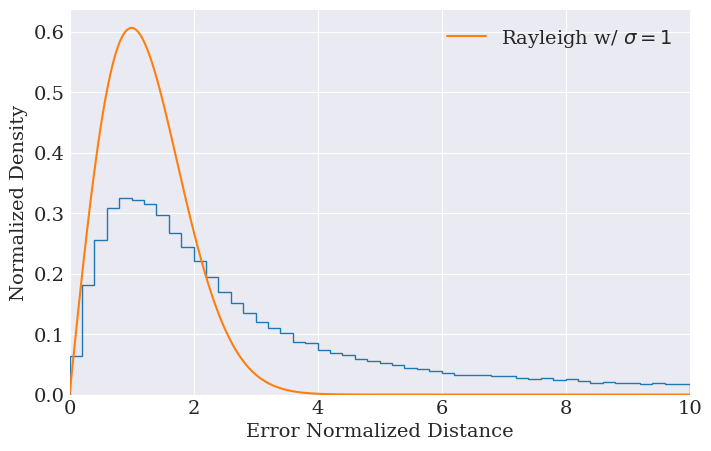

In [55]:
x_rayleigh = np.linspace(0, 10, 500)
y_rayleigh = rayleigh(x_rayleigh, 1)

fig, ax = plt.subplots(1,1, figsize=(8, 5))
ax.hist(D[D<10], bins=50, histtype='step', density=True)
ax.plot(x_rayleigh, y_rayleigh, label=r'Rayleigh w/ $\sigma = 1$')

ax.set_xlim(0, 10)

ax.set_xlabel('Error Normalized Distance')
ax.set_ylabel('Normalized Density')
ax.set_title('')
        
plt.legend()

## Compare Selection Methods

In [5]:
pos_10as = np.load(rpath+'final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_position.npy')
mag_10as = np.load(rpath+'final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_magnitude.npy')
near_10as =  np.load(rpath+'final_crossmatch+PMC+EIB_10as_best_neighbour_nearest.npy')

In [6]:
num_diff = 0
differing = []
for i in range(pos_10as.shape[0]):
    if not (pos_10as[i][0] == near_10as[i][0]):
        print('These Hipp identifiers do not match')
    if not pos_10as[i][1] == near_10as[i][1]:
        num_diff += 1
        differing.append(i)
print(f'The two selection methods do not agree on {num_diff} objects')

The two selection methods do not agree on 102 objects


## Investigate Proper Motion of matches. 
Here we investigate specifically the 10as crossmatch with the likeliest position

This might be a method, on top of the brightnesses to investigate whether or not two objects really match

In [6]:
hipp_10as_pos, gaia_10as_pos = get_hipp_gaia_data(pos_10as)

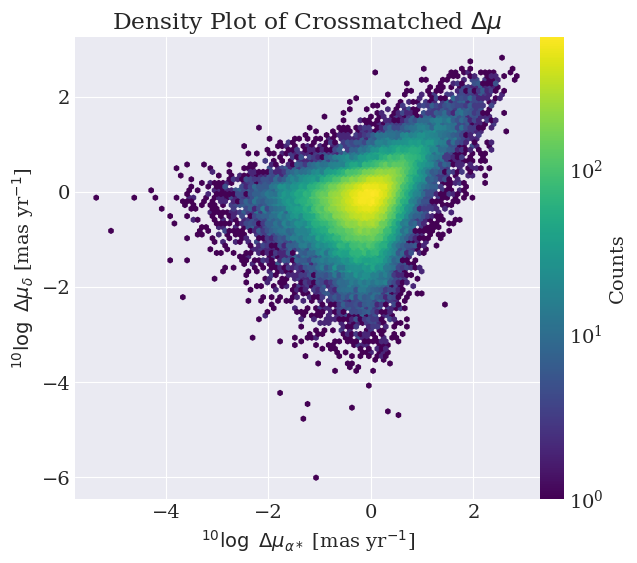

In [158]:
delta_pmra = np.abs(hipp_10as_pos['pm_ra'] - gaia_10as_pos['pmra_prop'])
delta_pmde = np.abs(hipp_10as_pos['pm_de'] - gaia_10as_pos['pmdec_prop'])
delta_pm = np.sqrt(delta_pmra**2 + delta_pmde**2)

fig, ax = plt.subplots(1,1,figsize=(6,6))
dens = ax.hexbin(np.log10(delta_pmra), np.log10(delta_pmde), bins='log', mincnt=1, cmap='viridis')


fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.9, 0.11, 0.04, 0.77])
cb = fig.colorbar(dens, cax=cbar_ax)

ax.set_xlabel(r'$^{10}\log~\Delta\mu_{\alpha*}$ [mas yr$^{-1}$]')
ax.set_ylabel(r'$^{10}\log~\Delta\mu_{\delta}$ [mas yr$^{-1}$]')
ax.set_title(r'Density Plot of Crossmatched $\Delta\mu$')
cb.set_label('Counts')


plt.savefig(fpath+'deltamu_dens_10as_pos.png', bbox_inches='tight')
plt.show()

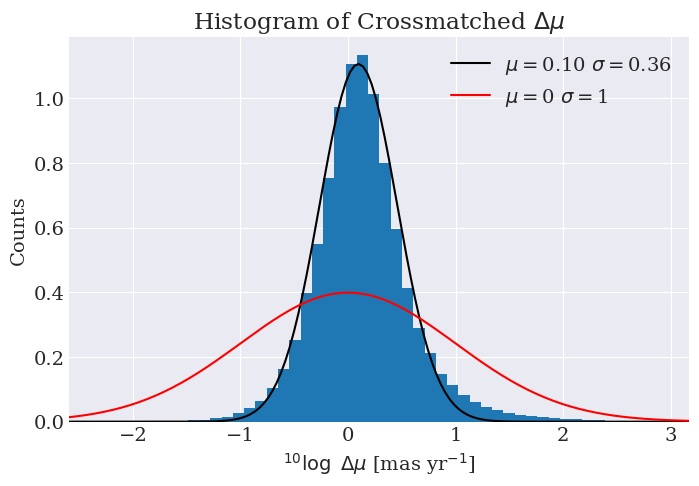

In [181]:
def gauss(x, mu, sigma):
    return (1./(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)**2)/(sigma**2))

x = np.linspace(-5, 5, 250)


fig, ax = plt.subplots(1,1, figsize=(8, 5))
n, bins, patches = ax.hist(np.log10(delta_pm), log=False, density=True, bins=50)
xlim = ax.get_xlim()

bin_centers = np.zeros(len(bins)-1)
for i in range(len(bin_centers)):
    bin_centers[i] = bins[i]+0.5*(bins[1]-bins[0])
popt, pcov = curve_fit(gauss, bin_centers, n)


ax.plot(x, gauss(x, *popt), c='black', label=fr'$\mu = ${popt[0]:.2f} $\sigma = ${popt[1]:.2f}')
ax.plot(x, gauss(x, 0, 1), c='red', label=fr'$\mu = $0 $\sigma = $1')

ax.set_xlabel(r'$^{10}\log~\Delta\mu$ [mas yr$^{-1}$]')
ax.set_ylabel('Counts')
ax.set_title(r'Histogram of Crossmatched $\Delta\mu$')

ax.set_xlim(xlim)

plt.legend()
plt.savefig(fpath+'deltamu_hist_10as_pos.png', bbox_inches='tight')
plt.show()

### Error Normalized Distance

In [7]:
# Make correct arrays
# pos = [ra, dec] ; unc = [sigma_ra^2, sigma_dec^2, rho_sigma_dec]
pos_hipp = np.array([hipp_10as_pos['ra'], hipp_10as_pos['dec']]).T * 3.6e6
pos_gaia = np.array([gaia_10as_pos['ra_prop'], gaia_10as_pos['dec_prop']]).T * 3.6e6
unc_hipp = np.array([hipp_10as_pos['e_ra_rad']**2, hipp_10as_pos['e_de_rad']**2, hipp_10as_pos['ra_dec_corr']]).T
unc_gaia = np.array([gaia_10as_pos['e_ra_prop']**2, gaia_10as_pos['e_de_prop']**2, gaia_10as_pos['ra_dec_prop']]).T

In [8]:
D = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='full')

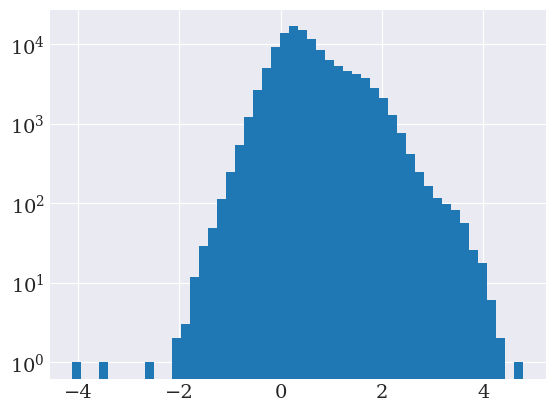

In [12]:
plt.hist(np.log10(D), log=True, bins=50)
plt.show()

### Match on Kervella

In [37]:
print(kervella_tab[1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional table                            NAXIS1  =                  620 / width of table in bytes                        NAXIS2  =               116017 / number of rows in table                        PCOUNT  =                    0 / heap size (no gap)                             GCOUNT  =                    1 / one data group                                 TFIELDS =                   87 / number of columns                              EXTNAME = 'result_1675677935118' / table name                                   TTYPE1  = 'recno   '           / label for column 1                             TFORM1  = 'J       '           / format for column 1                            TCOMM1  = 'Record number assigned by the VizieR team. Should Not be used for id'TUCD1   = 'meta.record'                 

In [31]:
hip_match_kervella = []
hip_nomatch_kervella = []
hip_not_in_kervella = []
for i in range(pos_10as.shape[0]):
    idx = np.where(pos_10as[i][0] == kervella_tab[1].data['HIP'])[0]
    if len(idx) > 0:
        if pos_10as[i][1] == kervella_tab[1].data['GaiaEDR3'][idx]:
            hip_match_kervella.append(i)
        else:
            hip_nomatch_kervella.append(i)

    else:
        hip_not_in_kervella.append(i)

In [32]:
print(f"""
Our XM Matches Kervella:    {len(hip_match_kervella)}
Our XM Doesn't Match   :    {len(hip_nomatch_kervella)}
Our Hip is not in Kervella: {len(hip_not_in_kervella)}""")


Our XM Matches Kervella:    115486
Our XM Doesn't Match   :    449
Our Hip is not in Kervella: 1877


In [44]:
# Setup a table with D, snrPMA
D_pmasnr = np.zeros((len(hip_match_kervella), 2))
for i in range(len(hip_match_kervella)):
    idx = np.where(pos_10as[hip_match_kervella[i]][0] == kervella_tab[1].data['HIP'])[0][0]
    D_pmasnr[i][0] = D[hip_match_kervella[i]]
    D_pmasnr[i][1] = kervella_tab[1].data['snrPMaH2EG3b'][idx]

/tmp/ipykernel_11979/3792984565.py:3: RuntimeWarning: divide by zero encountered in log10
  hbin = ax.hexbin(np.log10(D_pmasnr[: ,0]), np.log10(D_pmasnr[:, 1]), mincnt=1, bins='log', cmap='viridis')


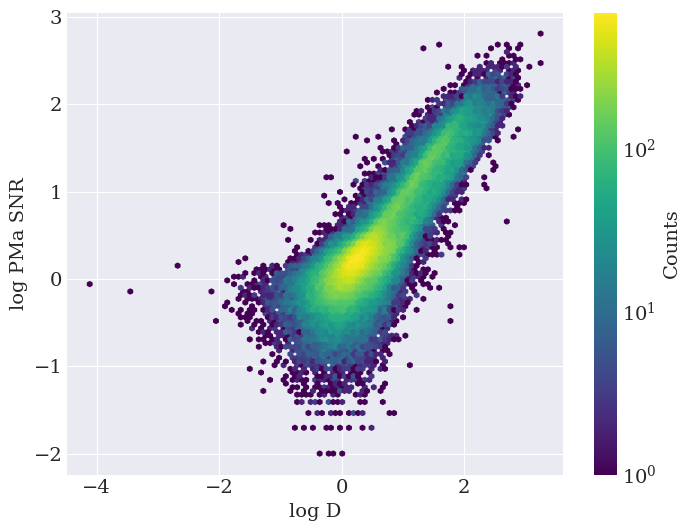

In [47]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

hbin = ax.hexbin(np.log10(D_pmasnr[: ,0]), np.log10(D_pmasnr[:, 1]), mincnt=1, bins='log', cmap='viridis')
cb = plt.colorbar(hbin)

ax.set_xlabel('log D')
ax.set_ylabel('log PMa SNR')
cb.set_label('Counts')

# Possible Report Plots

## 1. Presentation of the effect that selection based on nearest has on the G-Gpred spread

Add in a third plot with 10as_mag?

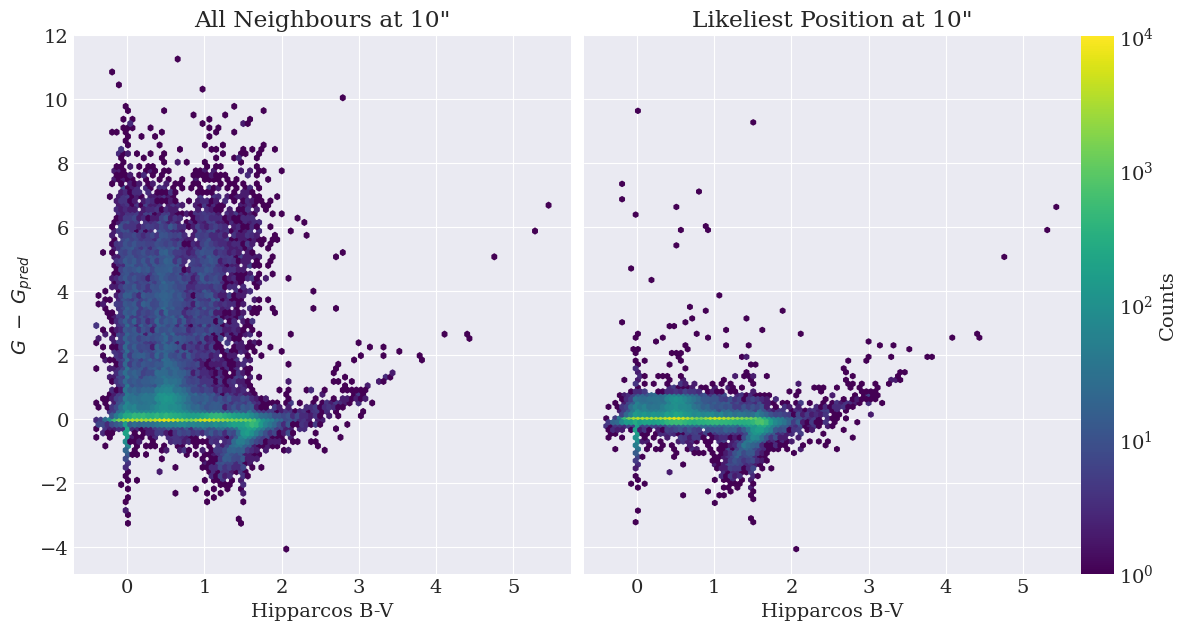

In [159]:
G_pred_all, _ = predict_G_bv(hipp_10as_all['hp_mag'], hipp_10as_all['b_v'])
G_pred_pos, _ = predict_G_bv(hipp_10as_pos['hp_mag'], hipp_10as_pos['b_v'])

# Plotting params
hexbin_kwargs = {
    'bins': 'log',
    'mincnt': 1,
    'cmap': 'viridis',
    'vmin': 1,
    'vmax': 1e4
}

fig, [ax0, ax1] = plt.subplots(1,2, figsize=(13, 7), sharey=True)#, tight_layout=True)



ax0.hexbin(hipp_10as_all['b_v'], gaia_10as_all['phot_g_mean_mag'] - G_pred_all, **hexbin_kwargs)
density = ax1.hexbin(hipp_10as_pos['b_v'], gaia_10as_pos['phot_g_mean_mag'] - G_pred_pos, **hexbin_kwargs)

# Spacing Shennanigans
fig.subplots_adjust(wspace=0.025)
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.9, 0.11, 0.025, 0.768])
cb = fig.colorbar(density, cax=cbar_ax)

# Titles
ax0.set_xlabel('Hipparcos B-V')
ax1.set_xlabel('Hipparcos B-V')
ax0.set_ylabel(r'$G~-~G_{pred}$')
ax0.set_title('All Neighbours at 10"')
ax1.set_title('Likeliest Position at 10"')
cb.set_label('Counts')

plt.savefig(fpath+'G_Gpred_comparison_10as_pos.png', bbox_inches='tight')
